In [27]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
data_dir = Path('/content/drive/MyDrive/IDXExchange_Training/data')

import pandas as pd
import numpy as np
from pathlib import Path
# Run in Anaconda Prompt or terminal if needed:
# pip install pandas numpy scikit-learn xgboost matplotlib joblib

# Confirming files exist
from pathlib import Path
data_dir = Path('/content/drive/MyDrive/IDXExchange_Training/data')
training_files = [
 'CRMLSSold202509.csv', 'CRMLSSold202510.csv',
 'CRMLSSold202511.csv', 'CRMLSSold202512.csv',
 'CRMLSSold202601.csv', 'CRMLSSold202602.csv',
]
test_file = 'CRMLSSold202603.csv'
for name in training_files + [test_file]:
 path = data_dir / name
 print(name, 'exists:', path.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CRMLSSold202509.csv exists: True
CRMLSSold202510.csv exists: True
CRMLSSold202511.csv exists: True
CRMLSSold202512.csv exists: True
CRMLSSold202601.csv exists: True
CRMLSSold202602.csv exists: True
CRMLSSold202603.csv exists: True


## Week 1

In [28]:
import pandas as pd
from pathlib import Path
data_dir = Path('/content/drive/MyDrive/IDXExchange_Training/data')
training_files = [
 data_dir / 'CRMLSSold202509.csv',
 data_dir / 'CRMLSSold202510.csv',
 data_dir / 'CRMLSSold202511.csv',
 data_dir / 'CRMLSSold202512.csv',
 data_dir / 'CRMLSSold202601.csv',
 data_dir / 'CRMLSSold202602.csv',
]
dfs = [pd.read_csv(f) for f in training_files]
df = pd.concat(dfs, ignore_index=True)
print('Combined training shape:', df.shape)

df = df[
 (df['PropertyType'] == 'Residential') &
 (df['PropertySubType'] == 'SingleFamilyResidence')
].copy()

numeric_cols = [
 'ClosePrice', 'BedroomsTotal', 'BathroomsTotalInteger', 'LivingArea',
 'LotSizeSquareFeet', 'YearBuilt', 'GarageSpaces', 'Stories',
 'Latitude', 'Longitude'
]
for col in numeric_cols:
 if col in df.columns:
  df[col] = pd.to_numeric(df[col], errors='coerce')

df = df[df['ClosePrice'] > 0].copy()
df = df[df['LivingArea'] > 0].copy()
df = df.dropna(subset=['ClosePrice', 'BedroomsTotal',
 'BathroomsTotalInteger', 'LivingArea', 'PostalCode']).copy()

/tmp/ipykernel_1582/4243774183.py:12: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs = [pd.read_csv(f) for f in training_files]


Combined training shape: (119913, 78)


In [29]:
# Sentinel fill: null GarageSpaces means no garage
df['GarageSpaces'] = df['GarageSpaces'].fillna(0)
# Median fill for columns with modest null rates
for col in ['LotSizeSquareFeet', 'YearBuilt', 'Stories', 'Latitude', 'Longitude']:
 if col in df.columns:
  df[col] = df[col].fillna(df[col].median())


df['PostalCode5'] = df['PostalCode'].astype(str).str.slice(0, 5)
df['City'] = df['City'].astype(str)
# These use the full training DataFrame -- do NOT include test data here
#df['zip_median_price'] = df.groupby('PostalCode5')['ClosePrice'].transform('median')
#df['city_median_price'] = df.groupby('City')['ClosePrice'].transform('median')

df_constrained = df[df['ClosePrice'] < 5_000_000].copy()


## Week 3

In [30]:
from sklearn.model_selection import train_test_split

# Features that do NOT depend on ClosePrice
base_features = [
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'LivingArea',
    'LotSizeSquareFeet',
    'YearBuilt',
    'GarageSpaces',
    'Stories',
    'Latitude',
    'Longitude',
    'PostalCode5',
    'City'
]

model_df = df_constrained[base_features + ['ClosePrice']].dropna().copy()

# Split BEFORE calculating ZIP/city median prices
train_df, val_df = train_test_split(
    model_df,
    test_size=0.20,
    random_state=42
)

# Calculate medians using TRAINING data only
zip_map = train_df.groupby('PostalCode5')['ClosePrice'].median()
city_map = train_df.groupby('City')['ClosePrice'].median()

# Use the overall training median as a fallback
global_median = train_df['ClosePrice'].median()

# Create ZIP/city median features for training
train_df['zip_median_price'] = (
    train_df['PostalCode5']
    .map(zip_map)
    .fillna(global_median)
)

train_df['city_median_price'] = (
    train_df['City']
    .map(city_map)
    .fillna(global_median)
)

# Create ZIP/city median features for validation
val_df['zip_median_price'] = (
    val_df['PostalCode5']
    .map(zip_map)
    .fillna(global_median)
)

val_df['city_median_price'] = (
    val_df['City']
    .map(city_map)
    .fillna(global_median)
)


In [31]:
feature_cols = [
 'BedroomsTotal', 'BathroomsTotalInteger', 'LivingArea', 'LotSizeSquareFeet',
 'YearBuilt', 'GarageSpaces', 'Stories', 'Latitude', 'Longitude',
 'zip_median_price', 'city_median_price'
]
X_train = train_df[feature_cols]
y_train = train_df['ClosePrice']

X_val = val_df[feature_cols]
y_val = val_df['ClosePrice']

In [32]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error
def mdape(y_true, y_pred):
 y_true = np.array(y_true)
 y_pred = np.array(y_pred)
 mask = y_true != 0
 ape = np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]) * 100
 return np.median(ape)

def regression_report(y_true, y_pred):
  return {
  'R2': r2_score(y_true, y_pred),
  'MAE': mean_absolute_error(y_true, y_pred),
  'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
  'MedianAbsoluteError': median_absolute_error(y_true, y_pred),
  'MDAPE': mdape(y_true, y_pred),
  }

## Week 5

## Deliverables

Trained XGBoost Model

In [33]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
 n_estimators=500,
 learning_rate=0.05,
 max_depth=6,
 subsample=0.85,
 colsample_bytree=0.85,
 objective='reg:squarederror',
 random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_val)
print('XGBoost (validation):', regression_report(y_val, xgb_preds))

XGBoost (validation): {'R2': 0.8864156137349567, 'MAE': 144613.54301327872, 'RMSE': np.float64(253747.41299222092), 'MedianAbsoluteError': np.float64(74605.28125), 'MDAPE': np.float64(8.882356890683734)}


Feature Importance Chart

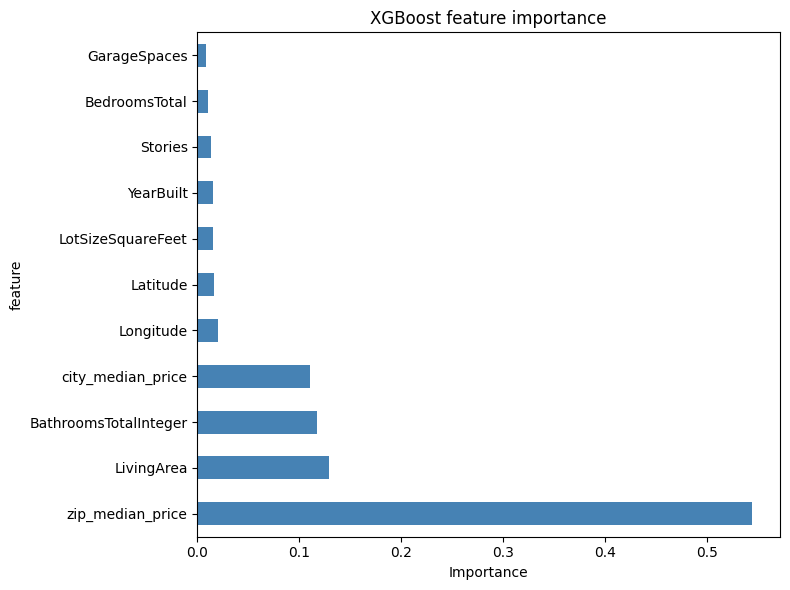

In [34]:
import matplotlib.pyplot as plt

output_dir = data_dir.parent / 'outputs'
output_dir.mkdir(exist_ok=True)

importance_df = pd.DataFrame({
 'feature': X_train.columns,
 'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)
importance_df.head(12).plot(kind='barh', x='feature', y='importance',
 figsize=(8, 6), legend=False, color='steelblue')
plt.xlabel('Importance')
plt.title('XGBoost feature importance')
plt.tight_layout()
plt.savefig(output_dir/'feature_importance.png', dpi=120)
plt.show()

Final Test Set Metrics

In [38]:
df_test = pd.read_csv(data_dir / 'CRMLSSold202603.csv')
df_test = df_test[
 (df_test['PropertyType'] == 'Residential') &
 (df_test['PropertySubType'] == 'SingleFamilyResidence') &
 (df_test['ClosePrice'] > 0) &
  (df_test['ClosePrice'] < 5_000_000)
].copy()

for col in numeric_cols:
 if col in df_test.columns:
  df_test[col] = pd.to_numeric(df_test[col], errors='coerce')

df_test['GarageSpaces'] = df_test['GarageSpaces'].fillna(0)
for col in ['LotSizeSquareFeet', 'YearBuilt', 'Stories', 'Latitude', 'Longitude']:
 if col in df_test.columns:
  df_test[col] = df_test[col].fillna(df[col].median()) # use training median

df_test['PostalCode5'] = df_test['PostalCode'].astype(str).str.slice(0, 5)
df_test['City'] = df_test['City'].astype(str)
df_test['zip_median_price'] = df_test['PostalCode5'].map(zip_map).fillna(global_median)
df_test['city_median_price'] = df_test['City'].map(city_map).fillna(global_median)

X_test = df_test[feature_cols].dropna()
y_test = df_test.loc[X_test.index, 'ClosePrice']
test_preds = xgb_model.predict(X_test)

print('Final test set metrics:', regression_report(y_test, test_preds))

Final test set metrics: {'R2': 0.8863280234519509, 'MAE': 149894.59131997928, 'RMSE': np.float64(262727.00044131617), 'MedianAbsoluteError': np.float64(78234.859375), 'MDAPE': np.float64(8.95862057843441)}


Final Prediction Function

In [36]:
def predict_close_price(model, input_dict, feature_cols):
 input_df = pd.DataFrame([input_dict])
 for col in feature_cols:
  if col not in input_df.columns:
    input_df[col] = 0
 return model.predict(input_df[feature_cols])[0]

sample_property = {
 'BedroomsTotal': 4, 'BathroomsTotalInteger': 3,
 'LivingArea': 2400, 'LotSizeSquareFeet': 6500,
 'YearBuilt': 1998, 'GarageSpaces': 2,
 'Stories': 2, 'Latitude': 34.121, 'Longitude': -117.891,
 'zip_median_price': 925000, 'city_median_price': 890000
}
print('Predicted ClosePrice:', predict_close_price(xgb_model, sample_property,
feature_cols))

Predicted ClosePrice: 1136651.8


Baseline Model and XGBoost Comparison

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Re-train baseline models for comparison
lr = LinearRegression()
lr.fit(X_train, y_train)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

lr_metrics  = regression_report(y_val, lr.predict(X_val))
rf_metrics  = regression_report(y_val, rf.predict(X_val))
xgb_metrics = regression_report(y_val, xgb_preds)

pd.DataFrame({
    'Metric':             list(lr_metrics.keys()),
    'Linear Regression':  list(lr_metrics.values()),
    'Random Forest':      list(rf_metrics.values()),
    'XGBoost':            list(xgb_metrics.values()),
}).set_index('Metric').round(2)

,Linear Regression,Random Forest,XGBoost
Metric,,,
R2,0.80,0.88,0.89
MAE,211444.63,148754.66,144613.54
RMSE,335965.21,265567.73,253747.41
MedianAbsoluteError,133189.24,72517.60,74605.28
MDAPE,15.28,8.47,8.88


- **XGBoost has the best performance overall**
  - Highest R² (0.89) and lowest MAE (144613.54)
  - Has the lowest RMSE of the models meaning it explains most variance with the smallest dollar error

- **Feature Importance**:
  - zip_median_price, living_area, bathrooms, and city_median_price were the strongest predictors
  - Location and living area are the strongest drivers of CA home prices
